In [ ]:
import json 
import numpy as np  
import pandas as pd  
import ast 
import seaborn as sns 
from utils.score import get_summary  
from utils.df import model_name_map

sns.set_theme(
    style="whitegrid",
    context="paper",
)

model_results = {} 
model_mc = get_summary('mmstar')
model_mc['question_id'] = model_mc['pid'].astype('Int64') 
model_mc = model_mc.drop_duplicates(subset=['model', 'question_id', 'condition']) 
model_mc['model'] = model_mc['model'].map(model_name_map)  
blind_model=model_mc[model_mc['condition'] == 'inst blind']
print(model_mc.model.unique(), model_mc.condition.unique()) 
mmstar_blind = pd.concat([blind_model[blind_model['pid'].isin(qids)], human_mc])
mmstar_blind.groupby(['model']).count()
ag = mmstar_blind.pivot_table(    
    index=['model'], 
    values=['correct'], 
    columns=['category'], 
    aggfunc=['mean'], # ,'count' 
    margins=True,
    margins_name='Total Average'
)

ag.to_latex('./tables/1_MMStar_human-pretrained-model_acc_cat.tex', float_format="%.1f")   
ag   

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Index(['﻿question_num', 'qid', 'answer', 'confidence', 'time_spent_seconds',
       'answer_timestamp', 'participant_id', 'question', 'answer_type',
       'answer_raw', 'answer_normalized', 'correct', 'index', 'category',
       'l2_category', 'meta_info', 'question_id', 'output', 'human_qid',
       'original_question', 'model'],
      dtype='object')

In [205]:
pt = model_mc.pivot_table(
    index=['model', 'category', 'l2_category', 'question_id'],
    values='correct',
    columns='condition',
    aggfunc='mean'
)
pt['Acc_Visual'] = pt['']
pt['Acc_Blind_inst'] = pt['inst blind']
pt['MG_Acc'] = pt[''] - pt['inst blind']
pt['Delta_Inst'] = pt['blind'] - pt['inst blind']
pt = pt.reset_index()
pt.groupby(['model']).mean(numeric_only=True).drop(columns=['', 'blind', 'inst blind', 'question_id']).to_latex(
            f'./tables/appendix/mmstar-mg_inst.tex', float_format="%.1f"
        )
pt[pt['question_id'].isin(qids)].pivot_table(
    index=['model'],
    values='MG_Acc',
    columns=['category', 'l2_category'],
    aggfunc='mean'
).to_latex(f'./tables/appendix/mmstar-mg_inst-blind_only-cat.tex', float_format="%.1f") 

category                coarse perception                        \
l2_category                 image emotion image scene and topic   
model                                                             
InternVL 3.5 (1B)               22.222222             32.653061   
InternVL 3.5 (2B)               22.222222             28.571429   
InternVL 3.5 (4B)               44.444444             36.734694   
InternVL 3.5 (8B)               33.333333             36.734694   
LLaVA-v1.5 (7B)                 33.333333             10.204082   
LLaVA-v1.6-Mistral (7B)         22.222222             24.489796   
LLaVA-v1.6-Vicuna (7B)          66.666667             12.244898   
Qwen3-VL (2B)                   44.444444             26.530612   
Qwen3-VL (4B)                   55.555556             38.775510   
Qwen3-VL (8B)                   22.222222             26.530612   

category                                      fine-grained perception  \
l2_category             image style & quality            localization   
model                                                                   
InternVL 3.5 (1B)                        40.0               23.076923   
InternVL 3.5 (2B)                        60.0               46.153846   
InternVL 3.5 (4B)                        60.0               61.538462   
InternVL 3.5 (8B)                        50.0               69.230769   
LLaVA-v1.5 (7B)                          50.0                0.000000   
LLaVA-v1.6-Mistral (7B)                  70.0               23.076923   
LLaVA-v1.6-Vicuna (7B)                   50.0               15.384615   
Qwen3-VL (2B)                            60.0               38.461538   
Qwen3-VL (4B)                            80.0               38.461538   
Qwen3-VL (8B)                            90.0               38.461538   

category                                             \
l2_category             object counting recognition   
model                                                 
InternVL 3.5 (1B)            -27.272727   10.909091   
InternVL 3.5 (2B)             15.151515   20.000000   
InternVL 3.5 (4B)             36.363636   29.090909   
InternVL 3.5 (8B)             15.151515   16.363636   
LLaVA-v1.5 (7B)               -6.060606    0.000000   
LLaVA-v1.6-Mistral (7B)        3.030303   10.909091   
LLaVA-v1.6-Vicuna (7B)         6.060606    1.818182   
Qwen3-VL (2B)                 30.303030   20.000000   
Qwen3-VL (4B)                 27.272727   21.818182   
Qwen3-VL (8B)                 36.363636   34.545455   

category                                instance reasoning  \
l2_category             cross-instance attribute reasoning   
model                                                        
InternVL 3.5 (1B)                                13.333333   
InternVL 3.5 (2B)                                33.333333   
InternVL 3.5 (4B)                                46.666667   
InternVL 3.5 (8B)                                60.000000   
LLaVA-v1.5 (7B)                                   0.000000   
LLaVA-v1.6-Mistral (7B)                          -6.666667   
LLaVA-v1.6-Vicuna (7B)                           20.000000   
Qwen3-VL (2B)                                    40.000000   
Qwen3-VL (4B)                                    46.666667   
Qwen3-VL (8B)                                    33.333333   

category                                                   \
l2_category             cross-instance relation reasoning   
model                                                       
InternVL 3.5 (1B)                                8.333333   
InternVL 3.5 (2B)                               25.000000   
InternVL 3.5 (4B)                               41.666667   
InternVL 3.5 (8B)                               25.000000   
LLaVA-v1.5 (7B)                                -16.666667   
LLaVA-v1.6-Mistral (7B)                        -25.000000   
LLaVA-v1.6-Vicuna (7B)                           8.333333   
Qwen3-VL (2B)                                

In [212]:
### MMStar questions 
with open('/home/work/yuna/HPA/evaluation/scored/humans/human_mc_per_question.json', 'r') as f:
    raw_data = json.load(f) 
human_mc = pd.DataFrame(raw_data)
df = human_mc.rename(columns={'\ufeffquestion_num': 'question_num'}) 
qids = human_mc.pid.unique()   
human_mc['question_id'] = human_mc['pid'].astype('Int64') 
human_mc['model'] = 'Humans'
human_mc['correct'] = human_mc['correct'] * 100
human_mc= human_mc[human_mc['participant_id']!= '13f54aa2_20251204_125847'] 
mm = pd.merge(blind_model, human_mc, on =['question_id', 'l2_category', 'category', 'answer'], how='left', suffixes=('_model', '_human')) 
mm = mm[(mm['question_id'].isin(qids))]
mm.iloc[0]['question_model'], mm.iloc[0]['question_human'] # .model.unique()   

('Which option describe the object relationship in the image correctly?\nOptions: A: The suitcase is on the book., B: The suitcase is beneath the cat., C: The suitcase is beneath the bed., D: The suitcase is beneath the book.',
 'Which option describe the object relationship in the image correctly?\nOptions: A: The suitcase is on the book., B: The suitcase is beneath the cat., C: The suitcase is beneath the bed., D: The suitcase is beneath the book.')

### Table 1 

In [ ]:
pt = model_mc.pivot_table( 
    index=['model', 'pid', 'category', 'l2_category'],  
    columns=['condition'],  
    values=['correct'],
    aggfunc=['mean'] # , 'count' 
) 
pt['MG'] = pt[('mean', 'correct', '')] - pt[('mean', 'correct', 'inst blind')] 
pt['inst_acc'] = pt[('mean', 'correct', 'inst blind')] - pt[('mean', 'correct', 'blind')] 
pt.to_csv(f'./tables/mmstar_model_MG_by_qid.csv') 
pt.columns = ['_'.join([str(i) for i in col if str(i) != '']).strip('_') for col in pt.columns.values]
pt = pt.reset_index()   

## Quadrants

In [247]:
mms = mm.groupby(['category', 'l2_category', 'question_id']).agg({'correct_human': 'mean', 'correct_model': 'mean'}).reset_index()
mms = pd.merge(mms, pt.groupby(['category', 'l2_category', 'question_id']).agg({'MG_Acc': 'mean'}).reset_index(), on=['category', 'l2_category', 'question_id']) # 'model', , 'correct_model': 'mean'
mms['dataset'] = 'MMStar'
mms.groupby(['model']).mean(numeric_only=True) 

,category,l2_category,question_id,correct_human,correct_model,MG_Acc,dataset
0,coarse perception,image emotion,9,30.000000,31.578947,-10.000000,MMStar
1,coarse perception,image emotion,13,60.000000,34.210526,10.000000,MMStar
2,coarse perception,image emotion,53,10.000000,44.736842,30.000000,MMStar
3,coarse perception,image emotion,68,63.157895,0.000000,70.000000,MMStar
4,coarse perception,image emotion,69,15.000000,0.000000,60.000000,MMStar
...,...,...,...,...,...,...,...
242,logical reasoning,diagram reasoning,936,25.000000,50.000000,60.000000,MMStar
243,logical reasoning,diagram reasoning,947,30.000000,42.105263,40.000000,MMStar
244,logical reasoning,diagram reasoning,949,20.000000,68.421053,30.000000,MMStar
245,logical reasoning,diagram reasoning,961,30.000000,5.263158,60.000000,MMStar


In [246]:
vqa_quadrants = pd.read_csv('./vqa_quadrants.csv')
vqa_quadrants['dataset'] = 'VQAv2'
mms=pd.concat([vqa_quadrants, mms]) 

In [242]:
mms.columns

Index(['Unnamed: 0', 'question_id', 'question_type', 'answer_type',
       'answer_similarity_model', 'answer_similarity_blind',
       'answer_similarity_inst_blind', 'correct_model', 'correct_blind',
       'correct_inst_blind', 'Acc_Visual', 'Acc_Blind_inst', 'MG_Acc',
       'S_Visual', 'S_Blind_inst', 'MG_S', 'Delta_Inst', 'meta_model', 'model',
       'question', 'answer', 'output', 'correct_human',
       'answer_similarity_human', 'human_correct', 'model_correct',
       'cc_quadrant', 'dataset', 'category', 'l2_category'],
      dtype='object')

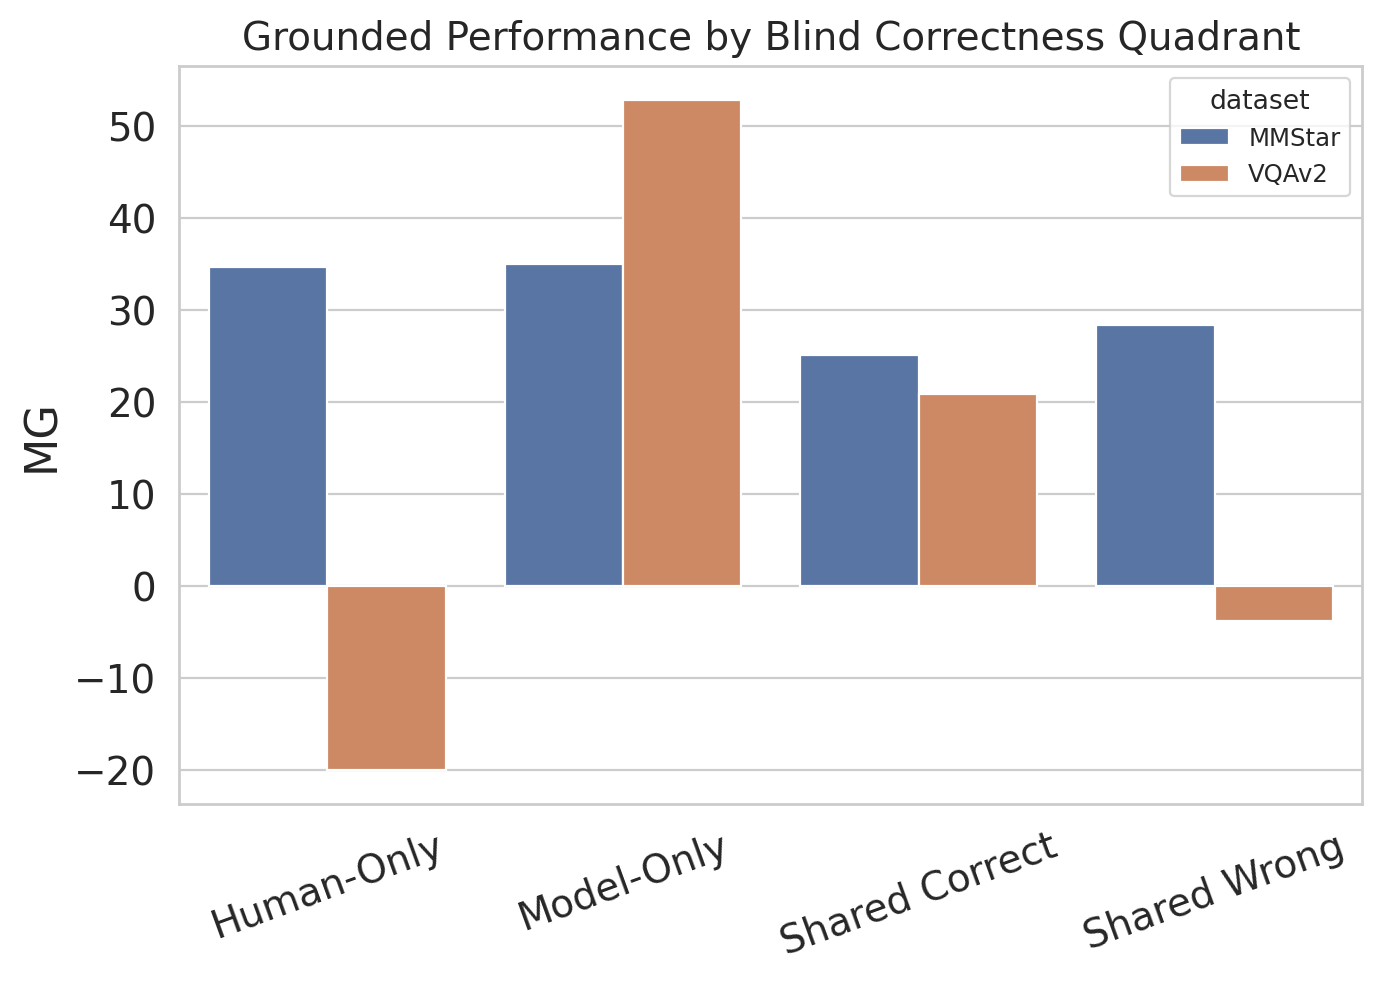

In [244]:
from utils.quadrants import *
import matplotlib.pyplot as plt 

mms["human_correct"] = (mms["correct_human"] >= 0.5).astype(int)  
mms["model_correct"] = (mms["correct_model"] >= 0.5).astype(int) 
mms["cc_quadrant"] = mms.apply(cc_quadrant, axis=1) 

plt.figure(figsize=(7, 5), dpi=200)  # Increase figure size and DPI for better quality

ax = sns.barplot(
    data=(
        mms.groupby(['dataset', "cc_quadrant"])["MG_Acc"]
        .mean()
        .reset_index()
    ),
    x="cc_quadrant",
    y="MG_Acc", 
    hue='dataset'
)

# Increase font sizes
ax.set_ylabel("MG", fontsize=16)
ax.set_xlabel("", fontsize=16)  # Blind Correctness Pattern
ax.set_title("Grounded Performance by Blind Correctness Quadrant", fontsize=14) 
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontsize(14)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Agreement 

In [ ]:
from utils.corr import plot_unified_agreement_heatmap  # get_agreements
from utils.ac1 import interrater_agreement_ac1 

metrics='correct' 
n_boot=200 
human_acc = human_mc.drop_duplicates(subset=['question_id', 'participant_id']).pivot(
        index=["category", "question_id"],
        columns="participant_id",
        values=metrics
    )
model_acc = blind_model.pivot_table( # .drop_duplicates(subset=['model', 'question_id'])
    index=["category", "question_id"], 
    columns="model",
    values=metrics, 
    aggfunc='mean'
) 
answers_pivot = human_acc.join(model_acc, how="inner")
humans = human_acc.columns
models = model_acc.columns
models  = ['InternVL 3.5 (1B)', 'InternVL 3.5 (2B)', 'InternVL 3.5 (4B)',
       'InternVL 3.5 (8B)', 'LLaVA-v1.5 (7B)', 'LLaVA-v1.6-Mistral (7B)',
       'LLaVA-v1.6-Vicuna (7B)','Qwen3-VL (2B)',
       'Qwen3-VL (4B)', 'Qwen3-VL (8B)',  'Qwen3 (4B)', 'Qwen3 (8B)', ] 
all_raters = list(humans) + list(models)

In [ ]:
answers_pivot = answers_pivot.reset_index() 

In [116]:
category_corr = []

for category in answers_pivot.category.unique():  

    res = interrater_agreement_ac1(
        answers_pivot[answers_pivot['category'] == category],
        grp1=humans,
        grp2=models,
        n_boot=0,
        ) 
    res['category'] = category 
    category_corr.append(res)
category_corr = pd.DataFrame(category_corr).dropna(axis=0, subset=['mean_r']).dropna(axis=1).drop(columns=['corr_mat', 'title', 'metric'])
category_corr.to_latex(f"./tables/appendix/mmstar-ac1-category.tex", float_format="%.1f")  

In [130]:
category_corr = []

for category in answers_pivot.category.unique():  

    res = interrater_agreement_ac1(
        answers_pivot[answers_pivot['category'] == category],
        grp1=humans,
        grp2=models,
        n_boot=0,
        ) 
    res['category'] = category 
    category_corr.append(res)

category_corr = pd.DataFrame(category_corr)
category_corr.dropna(axis=0, subset=['mean_r']).dropna(axis=1).drop(columns=['corr_mat', 'title', 'metric']).to_latex(f"./tables/appendix/mmstar-ac1-category.tex", float_format="%.1f")  

In [ ]:
model_corr = [] 
for i, cc in category_corr.iterrows(): 
    corr_mat=cc['corr_mat'].T.reset_index().melt(id_vars=['index'], var_name='subj', value_name='corr')    
    corr_mat['category'] = cc['category']
    model_corr.append(corr_mat) 
model_corr= pd.concat(model_corr)
model_corr.dropna()

,index,subj,corr,category
0,InternVL 3.5 (1B),02f952bb_20251210_230336,0.448276,coarse perception
1,InternVL 3.5 (2B),02f952bb_20251210_230336,0.623698,coarse perception
2,InternVL 3.5 (4B),02f952bb_20251210_230336,0.490885,coarse perception
3,InternVL 3.5 (8B),02f952bb_20251210_230336,0.480916,coarse perception
4,LLaVA-v1.5 (7B),02f952bb_20251210_230336,0.180106,coarse perception
...,...,...,...,...
235,Qwen3-VL (2B),f616d5c7_20251203_212223,-0.028777,logical reasoning
236,Qwen3-VL (4B),f616d5c7_20251203_212223,0.047244,logical reasoning
237,Qwen3-VL (8B),f616d5c7_20251203_212223,-0.181818,logical reasoning
238,Qwen3 (4B),f616d5c7_20251203_212223,-0.125984,logical reasoning


In [168]:
# model_corr.groupby(['index'])['corr'].mean().to_latex(f"./tables/appendix/mmstar-ac1-model.tex", float_format="%.1f") 
model_corr = model_corr.pivot_table(
    index='index', 
    columns=['category'], 
    values=['corr'], 
    aggfunc='mean'
)
model_corr.to_latex(f"./tables/appendix/mmstar-ac1-model-cat.tex", float_format="%.3f")  
model_corr 

corr                          \
category                coarse perception fine-grained perception   
index                                                               
InternVL 3.5 (1B)                0.375680                0.355762   
InternVL 3.5 (2B)                0.415034                0.443534   
InternVL 3.5 (4B)                0.386983                0.419558   
InternVL 3.5 (8B)                0.287350                0.372764   
LLaVA-v1.5 (7B)                  0.195631                0.414145   
LLaVA-v1.6-Mistral (7B)          0.358164                0.437181   
LLaVA-v1.6-Vicuna (7B)           0.299245                0.464113   
Qwen3 (4B)                       0.415512                0.304194   
Qwen3 (8B)                       0.444586                0.400733   
Qwen3-VL (2B)                    0.304713                0.388003   
Qwen3-VL (4B)                    0.438574                0.329424   
Qwen3-VL (8B)                    0.299055                0.422788   

                                                              
category                instance reasoning logical reasoning  
index                                                         
InternVL 3.5 (1B)                 0.365645          0.295850  
InternVL 3.5 (2B)                 0.453132          0.228304  
InternVL 3.5 (4B)                 0.390769          0.314116  
InternVL 3.5 (8B)                 0.435644         -0.136593  
LLaVA-v1.5 (7B)                   0.382508          0.240151  
LLaVA-v1.6-Mistral (7B)           0.449847          0.230977  
LLaVA-v1.6-Vicuna (7B)            0.312529          0.377256  
Qwen3 (4B)                        0.429729          0.227101  
Qwen3 (8B)                        0.484684         -0.193553  
Qwen3-VL (2B)                     0.386485          0.312420  
Qwen3-VL (4B)                     0.416434          0.184645  
Qwen3-VL (8B)                     0.328212         -0.032008

In [ ]:
hh_mean, hh_ci = interrater_agreement_ac1(answers_pivot, humans, humans, title="Human–Human", plot=False ) 
hm_mean, hm_ci = interrater_agreement_ac1(answers_pivot, humans, models, title="Human–Model", plot=False ) 
mm_mean, mm_ci = interrater_agreement_ac1(answers_pivot, models, models, title="Model–Model",  plot=False )  

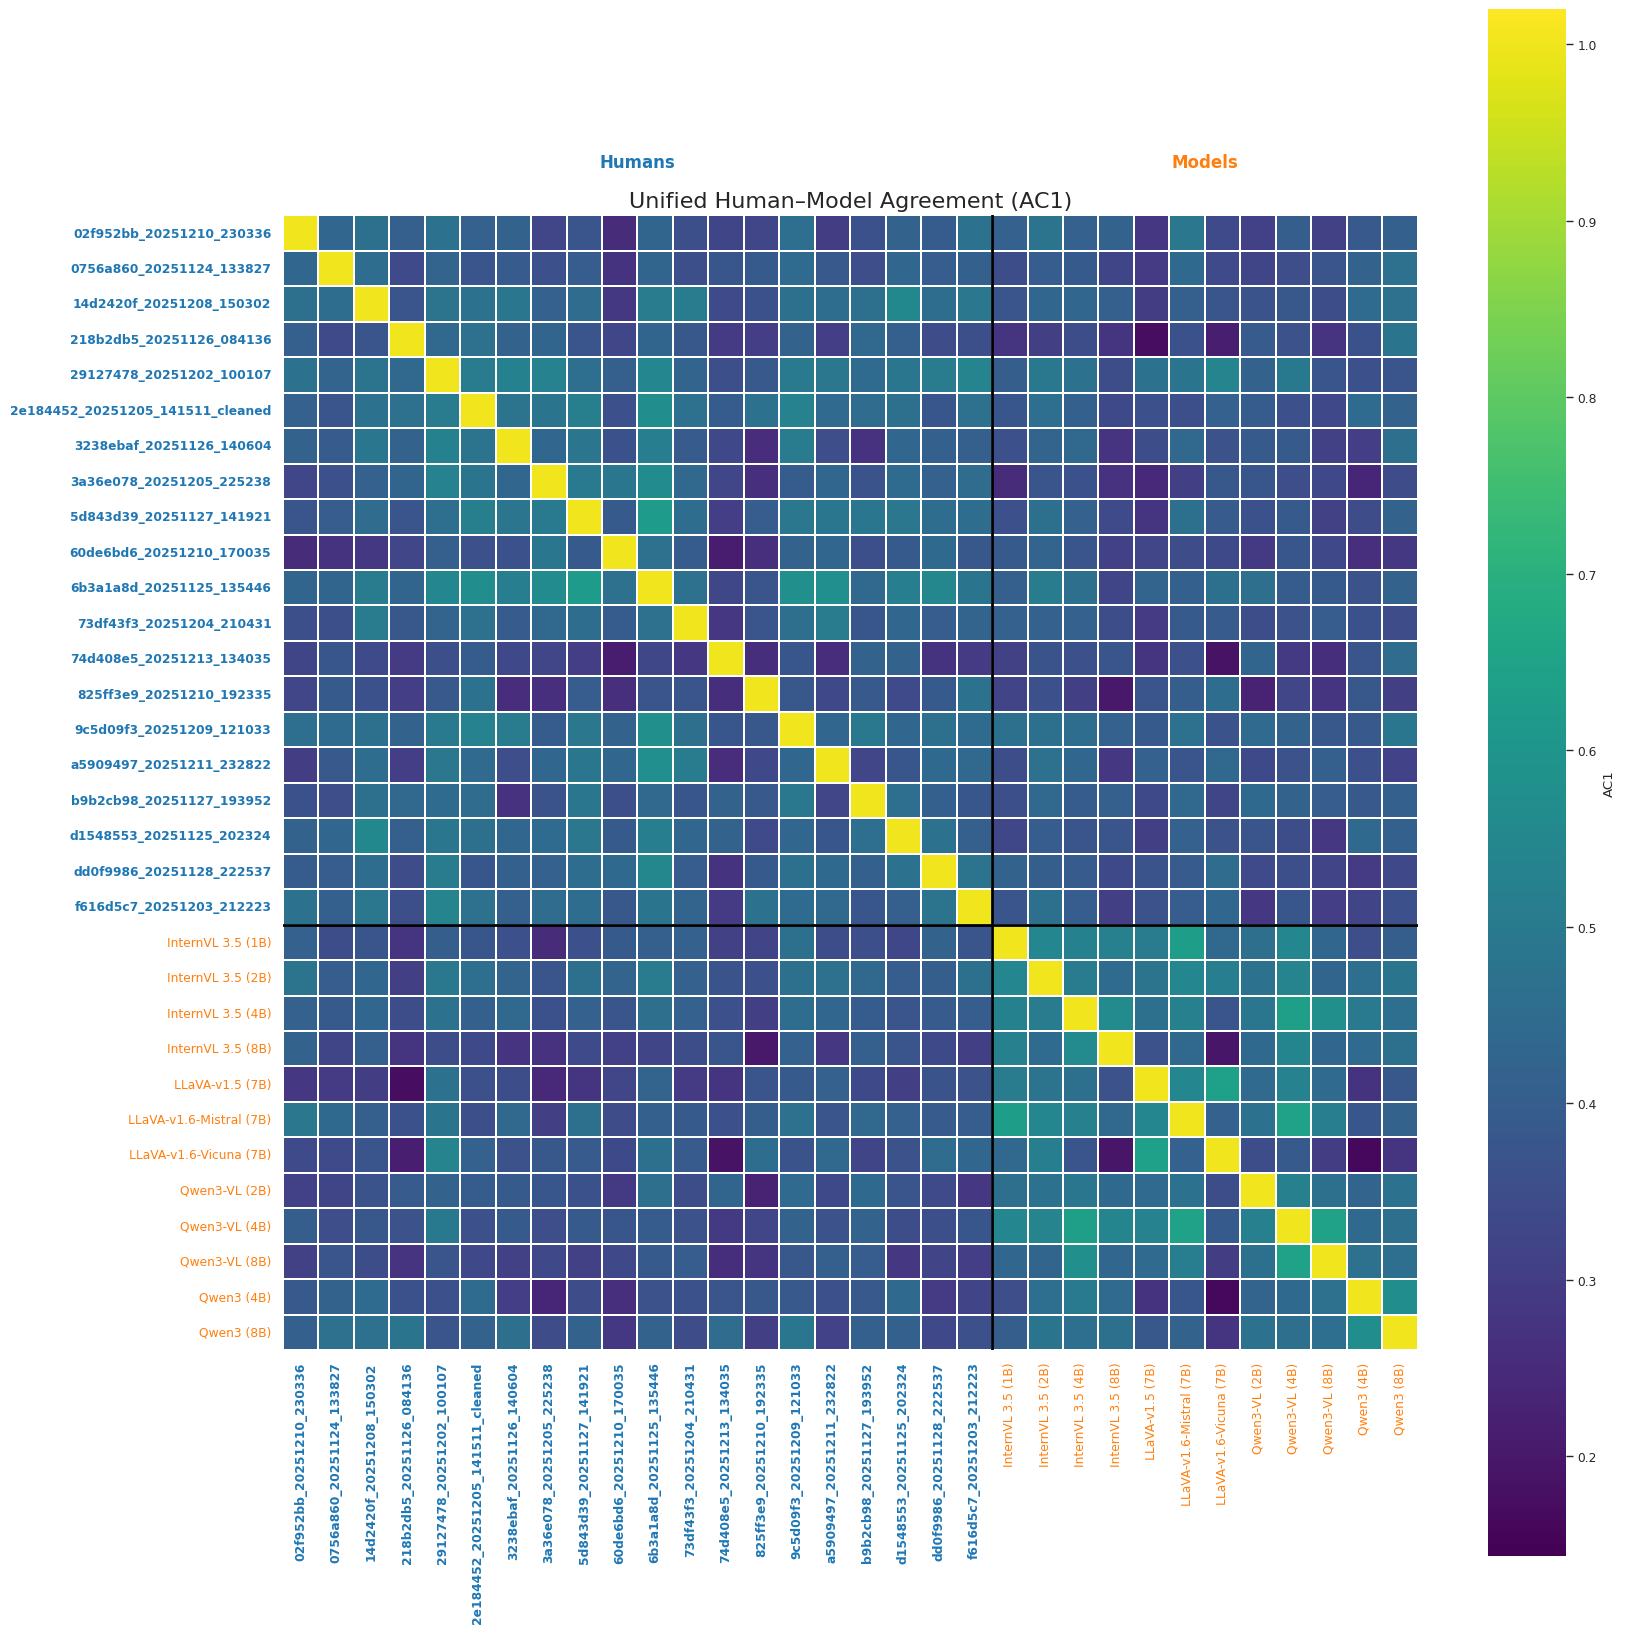

In [86]:
res = interrater_agreement_ac1(
    answers_pivot,
    grp1=all_raters,
    grp2=all_raters,
    n_boot=0,
    plot=True,
) 
res['corr_mat'] = res['corr_mat'].fillna(1)
plot_unified_agreement_heatmap(res['corr_mat'], list(humans), list(models), title="Unified Human–Model Agreement (AC1)", metric_label="AC1")

In [99]:
results = pd.merge(df.groupby(["category",	"l2_category"]).agg({'correct': 'mean', 'question':'nunique'}).reset_index(),
        blind.groupby(["category",	"l2_category"])['correct'].mean().reset_index(), 
        on=["category",	"l2_category"], suffixes=('_human', '_model')
        )
        
results['diff'] = np.abs(results['correct_model'] - results['correct_human'])
results.sort_values(by=['diff']) 

,category,l2_category,correct_human,question,correct_model,diff
8,instance reasoning,single-instance reasoning,0.343750,4,0.340909,0.002841
13,math,numeric commonsense and calculation,0.250000,1,0.242857,0.007143
10,logical reasoning,common reasoning,0.240385,13,0.232877,0.007508
3,fine-grained perception,localization,0.125000,1,0.083333,0.041667
2,coarse perception,image style & quality,0.250000,2,0.291667,0.041667
0,coarse perception,image emotion,0.375000,4,0.289474,0.085526
15,science & technology,biology & chemistry & physics,0.187500,2,0.100000,0.087500
5,fine-grained perception,recognition,0.321429,7,0.208333,0.113095
11,logical reasoning,diagram reasoning,0.166667,6,0.280488,0.113821
12,math,geometry,0.270000,25,0.390000,0.120000


In [84]:
blind = mmstar[mmstar['blind'] == True]
blind = blind.rename(columns={"index": 'qid'})
blind['qid'] = blind['qid'].astype(int)
blind = blind[blind['qid'].isin(df.qid.unique())]
len(blind.qid.unique())